In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("C:\\Users\\Luminar\\Desktop\\python_works\\collections\\nestedcollection\\penguine\\penguins.csv")

In [4]:
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [7]:
num_cols=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]

for col in num_cols:

    df[col]=df[col].fillna(df[col].mean())

In [8]:
df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
dtype: int64

In [9]:
df["sex"]=df["sex"].fillna(df["sex"].mode()[0])

In [10]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [11]:
df.to_csv("penguine_cleaned.csv",index=False)

In [12]:
fr = open("C:\\Users\\Luminar\\Desktop\\python_works\\collections\\nestedcollection\\penguine\\penguine_cleaned.csv")

In [13]:
from csv import DictReader



penguins = list(DictReader(fr))

### total number of penguines

In [14]:
print(len(penguins))

344


### First five records

In [15]:
for index,element in enumerate(penguins,start=1):

    if index==6:

        break

    print(element)




{'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': '39.1', 'bill_depth_mm': '18.7', 'flipper_length_mm': '181.0', 'body_mass_g': '3750.0', 'sex': 'MALE'}
{'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': '39.5', 'bill_depth_mm': '17.4', 'flipper_length_mm': '186.0', 'body_mass_g': '3800.0', 'sex': 'FEMALE'}
{'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': '40.3', 'bill_depth_mm': '18.0', 'flipper_length_mm': '195.0', 'body_mass_g': '3250.0', 'sex': 'FEMALE'}
{'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': '43.9219298245614', 'bill_depth_mm': '17.151169590643278', 'flipper_length_mm': '200.91520467836258', 'body_mass_g': '4201.754385964912', 'sex': 'MALE'}
{'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': '36.7', 'bill_depth_mm': '19.3', 'flipper_length_mm': '193.0', 'body_mass_g': '3450.0', 'sex': 'FEMALE'}


#### number of penguines in each species

In [16]:
species=[p.get("species") for p in penguins]
species_count = {sp:species.count(sp) for sp in species}

species_count

{'Adelie': 152, 'Chinstrap': 68, 'Gentoo': 124}

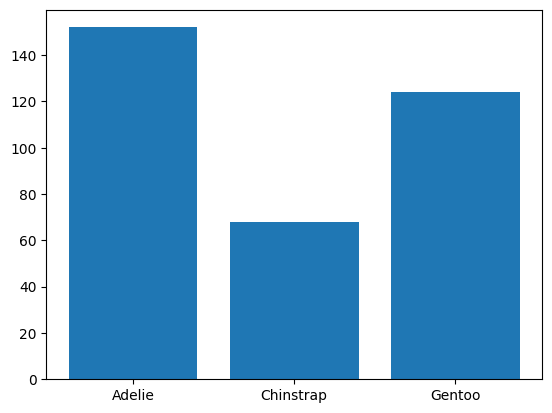

In [17]:
import matplotlib.pyplot as plt

plt.bar(species_count.keys(),species_count.values())

plt.show()

#### count th e number of penguines in each island

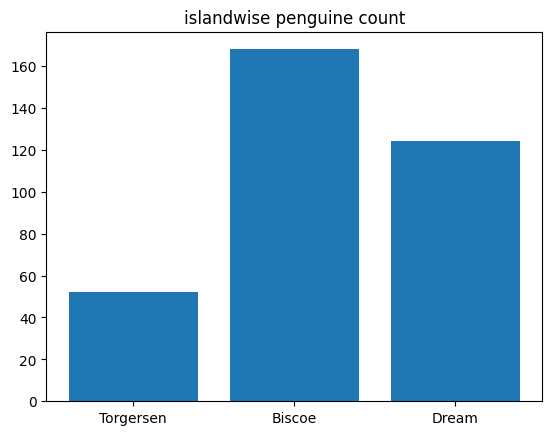

In [18]:
islands = [p["island"] for p in penguins]

island_count = {i:islands.count(i) for i in islands}

plt.title("islandwise penguine count")

plt.bar(island_count.keys(),island_count.values())

plt.show()

### number of male and female penguins

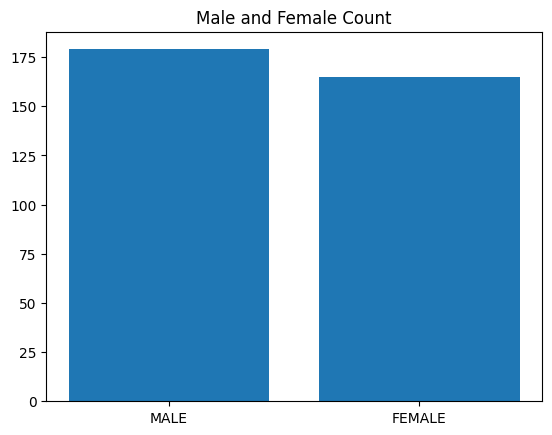

In [19]:
genders=[p["sex"] for p in penguins]

gender_count = {g:genders.count(g) for g in genders}

plt.title("Male and Female Count")
plt.bar(gender_count.keys(),gender_count.values())
plt.show()

# total body mass of all penguines

In [28]:
total_body_mass = sum([float(p["body_mass_g"]) for p in penguins])

total_body_mass

1445403.50877193

#### Avg body mass

In [27]:
avg_body_mass=sum([float(p["body_mass_g"]) for p in penguins])/ len(penguins)
avg_body_mass

4201.754385964912

### Highest body mass

In [26]:
highest_body_mass = max([float(p["body_mass_g"]) for p in penguins])
highest_body_mass

6300.0

### Fillper length avg

In [33]:
total_flipper_length_mm= sum([float(p["flipper_length_mm"]) for p in penguins])

print(total_flipper_length_mm/len(penguins))

200.91520467836258


### AVG body per species

In [34]:
penguins[0]

{'species': 'Adelie',
 'island': 'Torgersen',
 'bill_length_mm': '39.1',
 'bill_depth_mm': '18.7',
 'flipper_length_mm': '181.0',
 'body_mass_g': '3750.0',
 'sex': 'MALE'}

In [36]:
penguins[0]

{'species': 'Adelie',
 'island': 'Torgersen',
 'bill_length_mm': '39.1',
 'bill_depth_mm': '18.7',
 'flipper_length_mm': '181.0',
 'body_mass_g': '3750.0',
 'sex': 'MALE'}

In [ ]:

body_mass_summary = {}#"Adelie":{"avg_body_mass":3750.0,count:1}

for p in penguins:

    species = p["species"]

    body_mass_g = float(p["body_mass_g"])

    if species not in body_mass_summary:

        body_mass_summary[species]={"avg_body_mass":body_mass_g,"count":1}

    else:

        current_body_mass_g= body_mass_summary[species]["avg_body_mass"]

        count = body_mass_summary[species]["count"]

        body_mass_summary[species]["avg_body_mass"] = (body_mass_g+current_body_mass_g)/count+1
        
        body_mass_summary[species]["count"]+=1

body_mass_summary










{'Adelie': {'avg_body_mass': 27.661206713983102, 'count': 152},
 'Chinstrap': {'avg_body_mass': 58.298942865342006, 'count': 68},
 'Gentoo': {'avg_body_mass': 45.26035355679467, 'count': 124}}

In [38]:
penguins[0]

{'species': 'Adelie',
 'island': 'Torgersen',
 'bill_length_mm': '39.1',
 'bill_depth_mm': '18.7',
 'flipper_length_mm': '181.0',
 'body_mass_g': '3750.0',
 'sex': 'MALE'}

In [ ]:
island_summary = {} # {"Torgersen":{"avg_body_mass":3850,count:1}}

for p in penguins:

    island = p["island"]#Torgerson

    body_mass_g = float(p["body_mass_g"])#3750

    if island not in island_summary:

        island_summary[island]={"avg_body_mass":body_mass_g,"count":1}

    else:

        curent_body_mass_g = island_summary[island]["avg_body_mass"]#3850

        count = island_summary[island]["count"]#1

        island_summary[island]["avg_body_mass"] = (curent_body_mass_g+body_mass_g)/count+1

        island_summary[island]["count"]+=1

island_summary



{'Torgersen': {'avg_body_mass': 70.98391757832478, 'count': 52},
 'Biscoe': {'avg_body_mass': 33.53019388116047, 'count': 168},
 'Dream': {'avg_body_mass': 31.974573049036113, 'count': 124}}

In [41]:
df = pd.read_csv("C:\\Users\\Luminar\\Desktop\\python_works\\collections\\nestedcollection\\penguine\\tips.csv")

In [42]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64